covert and upload

In [1]:
import pandas as pd


df = pd.read_parquet('Syn-training.parquet')
df.to_csv('Syn-training.csv', index=False)

In [2]:
import pandas as pd
import os

# List of Parquet files and desired CSV names
parquet_files = {
    "Syn-training.parquet": "Syn-training.csv",
    "UDP-training.parquet": "UDP-training.csv",
    "NetBIOS-training.parquet": "NetBIOS-training.csv",
    "LDAP-training.parquet": "LDAP-training.csv",
    "UDPLag-training.parquet": "UDPLag-training.csv"
}

for parquet_file, csv_file in parquet_files.items():
    df = pd.read_parquet(parquet_file)
    df.to_csv(csv_file, index=False)
    print(f"Saved {csv_file}")


Saved Syn-training.csv
Saved UDP-training.csv
Saved NetBIOS-training.csv
Saved LDAP-training.csv
Saved UDPLag-training.csv


In [3]:
import pandas as pd


df = pd.read_parquet('UDP-training.parquet')
df.to_csv('UDP-training.csv', index=False)


df = pd.read_parquet('LDAP-training.parquet')
df.to_csv('LDAP-training.csv', index=False)


df = pd.read_parquet('NetBIOS-training.parquet')
df.to_csv('NetBIOS-training.csv', index=False)


df = pd.read_parquet('UDPLag-training.parquet')
df.to_csv('UDPLag-training.csv', index=False)


df = pd.read_parquet('SNMP-testing.parquet')
df.to_csv('SNMP-testing.csv', index=False)


In [4]:
# File paths and attack type mapping ===
file_paths = {
    "Syn-training.csv": "SYN",
    "UDP-training.csv": "UDP",
    "NetBIOS-training.csv": "NetBIOS",
    "LDAP-training.csv": "LDAP",
    "UDPLag-training.csv": "UDPLag",
    "SNMP-testing.csv": "SNMP"
}

# Load and label each file ===
dfs = []
for file, label in file_paths.items():
    df = pd.read_csv(file, low_memory=False)
    df["attack_type"] = label
    dfs.append(df)

# Combine all datasets into one ===
combined_df = pd.concat(dfs, ignore_index=True)

# Drop unnecessary identifier columns ===
drop_cols = ["Flow ID", "Src IP", "Src Port", "Dst IP", "Dst Port", "Timestamp"]
combined_df.drop(columns=[col for col in drop_cols if col in combined_df.columns], inplace=True)

# Drop columns with constant values ===
combined_df = combined_df.loc[:, combined_df.nunique() > 1]

# Drop all-NaN columns and rows with NaN or Inf ===
combined_df = combined_df.dropna(axis=1, how='all')
combined_df = combined_df.replace([float("inf"), float("-inf")], pd.NA)
combined_df = combined_df.dropna()

# Add numeric label for multiclass classification ===
combined_df["label"] = combined_df["attack_type"].astype("category").cat.codes

# Save cleaned dataset ===
combined_df.to_csv("cleaned_full_dataset.csv", index=False)
print("Saved cleaned_full_dataset.csv")

Saved cleaned_full_dataset.csv


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Cleaned Dataset ===
df = pd.read_csv("cleaned_full_dataset.csv")

# Sample to prevent memory errors ===
sampled_df = df.sample(n=20000, random_state=42)

# Separate features and labels ===
X = sampled_df.drop(columns=["attack_type", "label"])
X = X.select_dtypes(include=['number'])  # 🔥 Keep only numeric features
y = sampled_df["label"]

# Normalize Features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Train/Validation/Test Split ===
# First split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled_df, y, test_size=0.30, random_state=42, stratify=y
)

# Split the dataset ===

# First split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled_df, y, test_size=0.30, random_state=42, stratify=y
)

# Then split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Save the splits ===
X_train.to_csv("X_train.csv", index=False)
y_train.to_csv("y_train.csv", index=False)

X_val.to_csv("X_val.csv", index=False)
y_val.to_csv("y_val.csv", index=False)

X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Train/Val/Test splits saved.")

Train/Val/Test splits saved.


Validation Accuracy: 0.7940

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.31      0.44       173
           1       0.00      0.00      0.00        46
           2       0.74      0.54      0.62       104
           3       0.80      1.00      0.89      1878
           4       0.78      0.84      0.81       471
           5       0.75      0.01      0.02       328

    accuracy                           0.79      3000
   macro avg       0.63      0.45      0.46      3000
weighted avg       0.77      0.79      0.73      3000



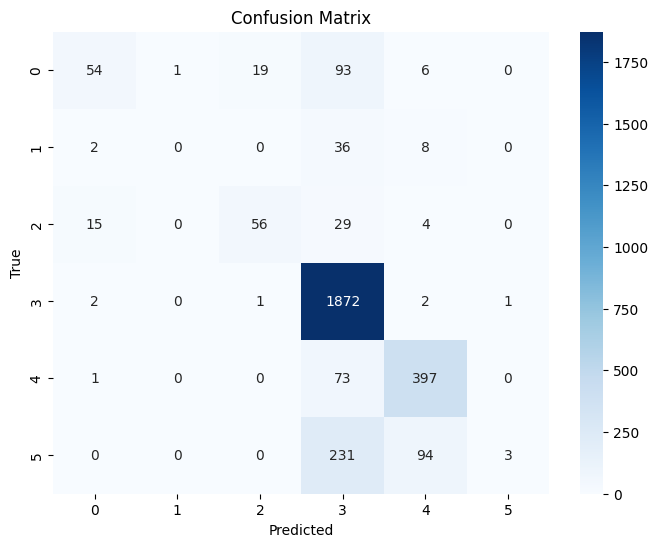

Trained SVM model saved as 'svm_multiclass_model.joblib'


In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump
import matplotlib.pyplot as plt
import seaborn as sns

# Load Train and Validation Data ===
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()

X_val = pd.read_csv("X_val.csv")
y_val = pd.read_csv("y_val.csv").squeeze()

# Train SVM Classifier (Multiclass) ===
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

# Evaluate on Validation Set ===
y_pred = model.predict(X_val)

# Accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Save the Trained Model ===
dump(model, "svm_multiclass_model.joblib")
print("Trained SVM model saved as 'svm_multiclass_model.joblib'")

Test Accuracy: 0.7853

Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.21      0.31       173
           1       0.00      0.00      0.00        47
           2       0.70      0.40      0.51       104
           3       0.79      1.00      0.88      1878
           4       0.78      0.86      0.82       470
           5       0.33      0.01      0.01       328

    accuracy                           0.79      3000
   macro avg       0.53      0.41      0.42      3000
weighted avg       0.71      0.79      0.72      3000



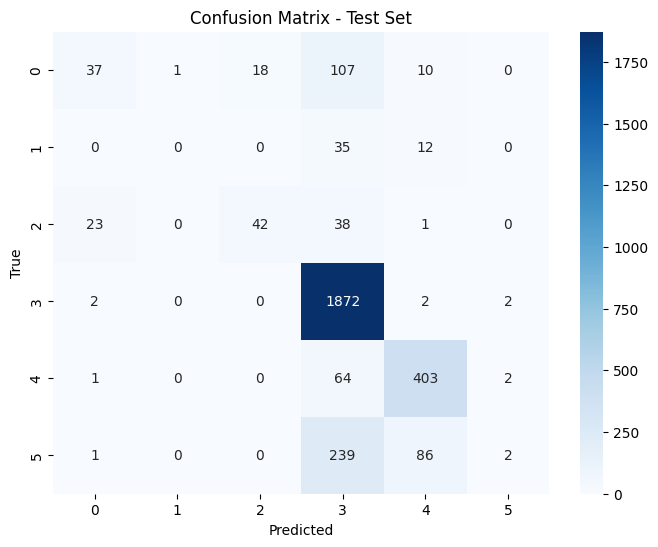

In [7]:
from joblib import load
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load Test Set and Trained Model ===
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").squeeze()

model = load("svm_multiclass_model.joblib")

# Predict and Evaluate ===
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from joblib import dump

#  Load Training Data ===
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()

# Define a Small, Efficient Parameter Grid ===
param_grid = {
    'C': [1, 10],                  # Smaller range of regularization values
    'gamma': ['scale', 0.01],      # Keep 'scale' + one manual
    'kernel': ['rbf'],             # Only RBF kernel
}

# Setup Grid Search with class_weight='balanced' ===
svc = SVC(class_weight='balanced')

grid = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1  # Use all available CPU cores
)

# Fit the Grid Search ===
grid.fit(X_train, y_train)

# Print the Best Parameters ===
print("Best Parameters Found:")
print(grid.best_params_)

# Save the Best Model ===
best_model = grid.best_estimator_
dump(best_model, "svm_best_model.joblib")
print("Best SVM model saved as 'svm_best_model.joblib'")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters Found:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM model saved as 'svm_best_model.joblib'
